In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import pandas as pd

# dataset load
df = pd.read_csv("/content/open_prescribing _data.csv")

# selected medicines
mental_health_drugs = [
    "Sertraline",
    "Fluoxetine",
    "Diazepam",
    "Lorazepam"
]

# filter rows
filtered_df = df[
    df["BNF_CHEMICAL_SUBSTANCE"].str.contains(
        "|".join(mental_health_drugs),
        case=False,
        na=False
    )
]

# shape check
print(filtered_df.shape)

# preview
filtered_df.head()

(330011, 27)


,YEAR_MONTH,REGIONAL_OFFICE_NAME,REGIONAL_OFFICE_CODE,ICB_NAME,ICB_CODE,PCO_NAME,PCO_CODE,PRACTICE_NAME,PRACTICE_CODE,ADDRESS_1,...,BNF_PRESENTATION_NAME,BNF_CHAPTER_PLUS_CODE,QUANTITY,ITEMS,TOTAL_QUANTITY,ADQ_USAGE,NIC,ACTUAL_COST,UNIDENTIFIED,SNOMED_CODE
0,2026-03,UNIDENTIFIED,-,UNIDENTIFIED,-,UNIDENTIFIED,-,UNIDENTIFIED DOCTORS,-,-,...,Diazepam 5mg tablets,04: Central Nervous System,1,1,1,0.5,0.02,0.12839,Y,42128311000001104
1,2026-03,MIDLANDS,Y60,NHS STAFFORDSHIRE AND STOKE-ON-TRENT INTEGRATE...,QNC,NHS STAFFORDSHIRE AND STOKE-ON-TRENT ICB - 05Q,05Q00,RIVERSIDE SURGERY,M83111,RIVERSIDE SURGERY,...,Lorazepam 1mg tablets,04: Central Nervous System,3,4,12,4.8,0.72,1.02531,N,42131511000001102
2,2026-03,NORTH WEST,Y62,NHS GREATER MANCHESTER INTEGRATED CARE BOARD,QOP,NHS GREATER MANCHESTER ICB - 00V,00V00,TOWNSIDE SURGERY,P83005,TOWNSIDE PCC-KNOWSLEY PL,...,Sertraline 50mg tablets,04: Central Nervous System,56,7,392,392.0,10.22,8.25871,N,39704111000001102
3,2026-03,NORTH WEST,Y62,NHS CHESHIRE AND MERSEYSIDE INTEGRATED CARE BOARD,QYG,WIRRAL COMMUNITY HEALTH AND CARE NHS FOUNDATIO...,RY700,WIRRAL WIC (APH)_WIC APH,N85645,ARROWE PARK HOSPITAL,...,Diazepam 2mg tablets,04: Central Nervous System,12,2,24,4.8,0.54,0.65658,N,42128111000001101
4,2026-03,NORTH EAST AND YORKSHIRE,Y63,NHS SOUTH YORKSHIRE INTEGRATED CARE BOARD,QF7,ROTHERHAM DONCASTER AND SOUTH HUMBER NHS FOUND...,RXE00,RDASH NTH LINCS COMMUNITY MH SERVICE,Y06949,MERIDIAN HOUSE,...,Diazepam 10mg tablets,04: Central Nervous System,14,1,14,14.0,0.37,0.40825,N,42127711000001101


monthly trend analysis chart

YEAR_MONTH
2026-03    113018838
Name: TOTAL_QUANTITY, dtype: int64


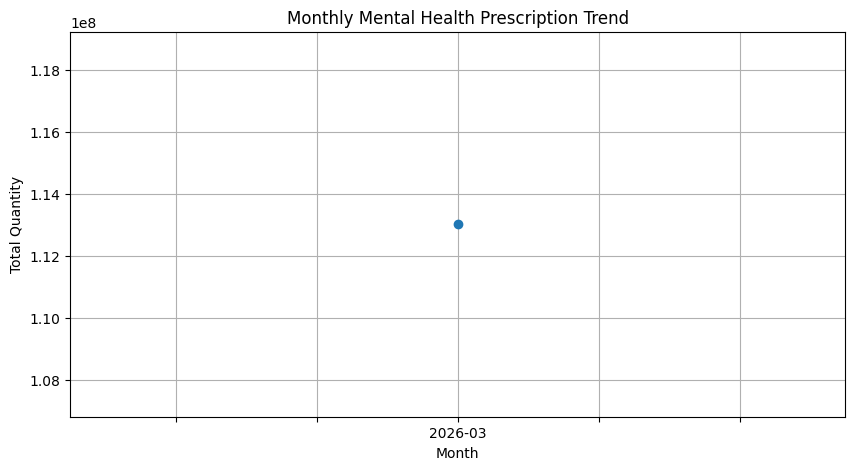

In [3]:
import matplotlib.pyplot as plt

# monthly quantity summary
monthly_trend = filtered_df.groupby("YEAR_MONTH")["TOTAL_QUANTITY"].sum()

print(monthly_trend)

# plot
plt.figure(figsize=(10,5))

monthly_trend.plot(marker='o')

plt.title("Monthly Mental Health Prescription Trend")
plt.xlabel("Month")
plt.ylabel("Total Quantity")
plt.grid(True)

plt.show()

REGIONAL_OFFICE_NAME
MIDLANDS                    23132765
NORTH EAST AND YORKSHIRE    20608859
SOUTH EAST                  17090162
NORTH WEST                  16653420
EAST OF ENGLAND             12820311
SOUTH WEST                  11759994
LONDON                      10947126
UNIDENTIFIED                    6201
Name: TOTAL_QUANTITY, dtype: int64


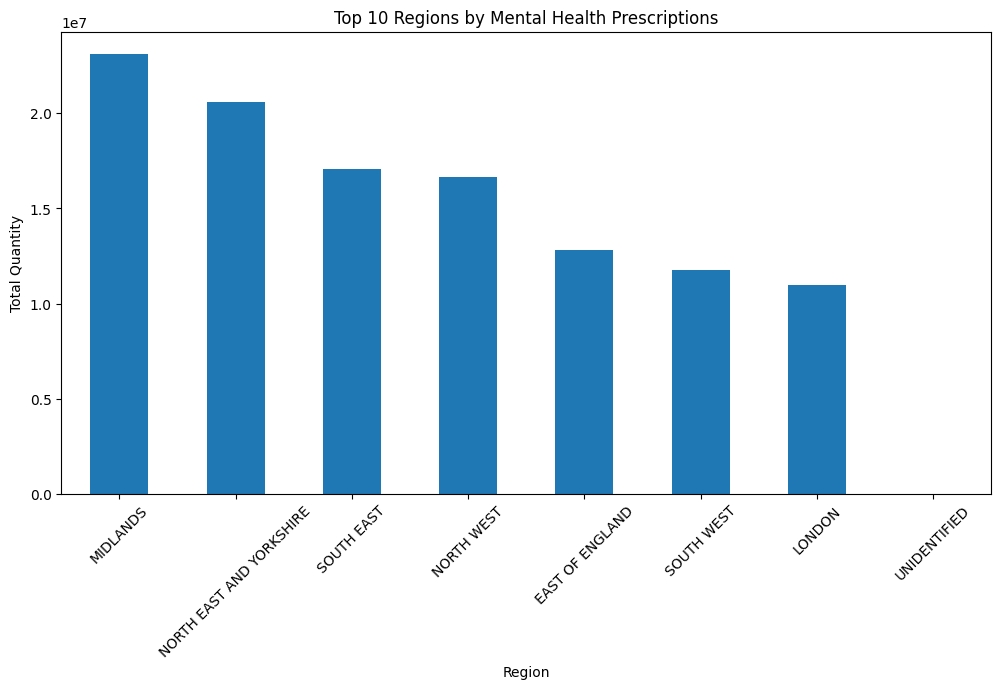

In [4]:
# regional analysis

regional_summary = filtered_df.groupby(
    "REGIONAL_OFFICE_NAME"
)["TOTAL_QUANTITY"].sum().sort_values(ascending=False).head(10)

print(regional_summary)

# chart
plt.figure(figsize=(12,6))

regional_summary.plot(kind='bar')

plt.title("Top 10 Regions by Mental Health Prescriptions")
plt.xlabel("Region")
plt.ylabel("Total Quantity")

plt.xticks(rotation=45)

plt.show()

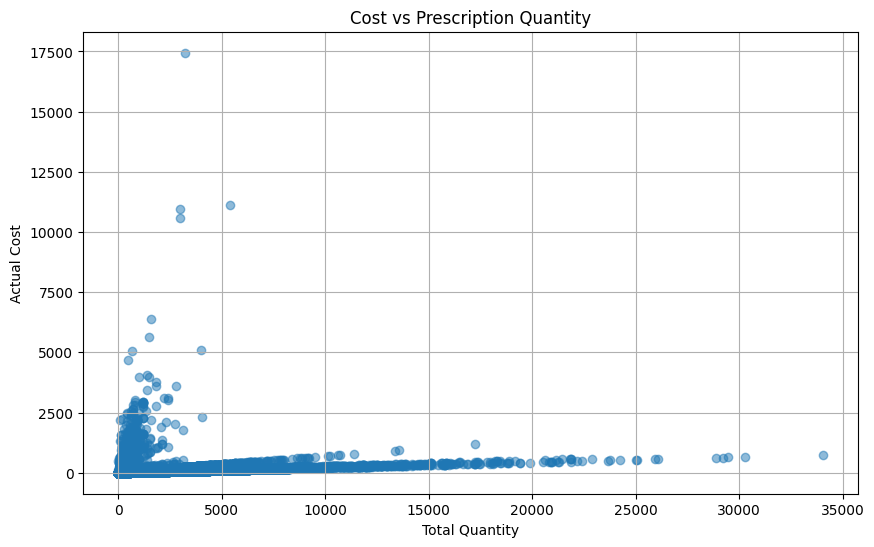

In [5]:
plt.figure(figsize=(10,6))

plt.scatter(
    filtered_df["TOTAL_QUANTITY"],
    filtered_df["ACTUAL_COST"],
    alpha=0.5
)

plt.title("Cost vs Prescription Quantity")
plt.xlabel("Total Quantity")
plt.ylabel("Actual Cost")

plt.grid(True)

plt.show()

drug wise trend

In [6]:
drug_summary = filtered_df.groupby(
    "BNF_CHEMICAL_SUBSTANCE"
)["TOTAL_QUANTITY"].sum().sort_values(ascending=False)

print(drug_summary.head(10))

BNF_CHEMICAL_SUBSTANCE
Sertraline hydrochloride    73537384
Fluoxetine hydrochloride    29041935
Diazepam                     7977282
Lorazepam                    2462237
Name: TOTAL_QUANTITY, dtype: int64


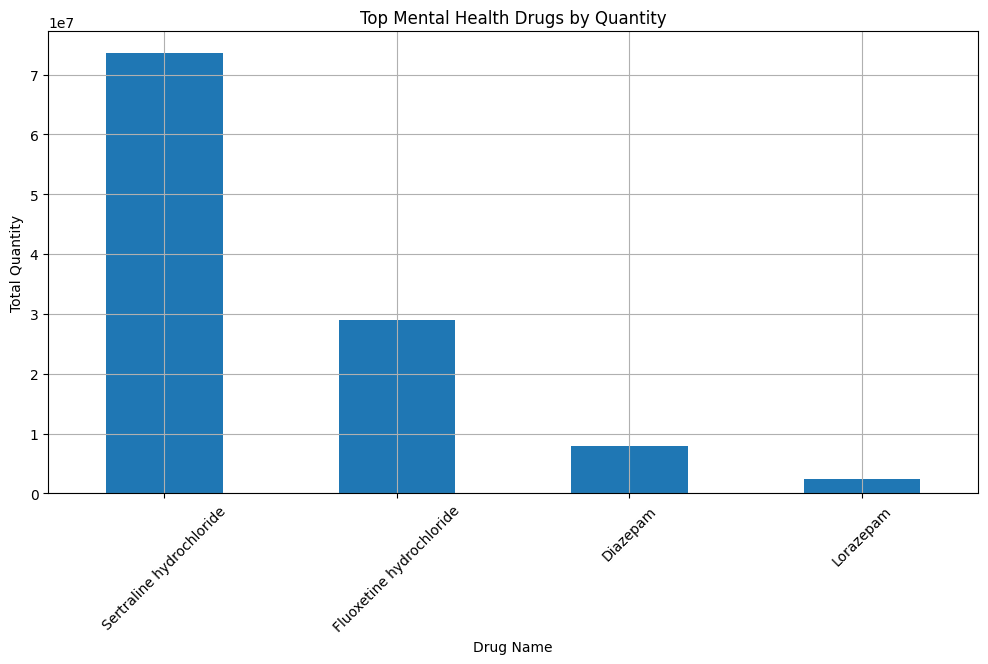

In [7]:
plt.figure(figsize=(12,6))

drug_summary.head(10).plot(kind='bar')

plt.title("Top Mental Health Drugs by Quantity")
plt.xlabel("Drug Name")
plt.ylabel("Total Quantity")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

In [8]:
# category mapping

filtered_df["CATEGORY"] = filtered_df["BNF_CHEMICAL_SUBSTANCE"].apply(
    lambda x: "Antidepressant"
    if x in ["Sertraline hydrochloride", "Fluoxetine hydrochloride"]
    else "Anxiolytic"
)

# category summary
category_summary = filtered_df.groupby(
    "CATEGORY"
)["TOTAL_QUANTITY"].sum()

print(category_summary)

CATEGORY
Antidepressant    102579319
Anxiolytic         10439519
Name: TOTAL_QUANTITY, dtype: int64


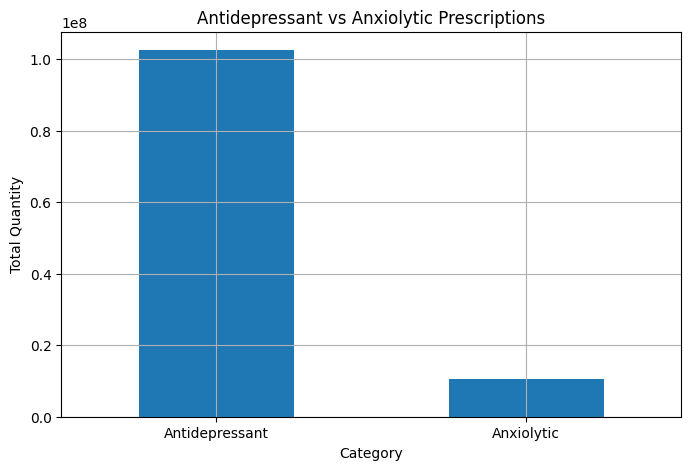

In [9]:
plt.figure(figsize=(8,5))

category_summary.plot(kind='bar')

plt.title("Antidepressant vs Anxiolytic Prescriptions")
plt.xlabel("Category")
plt.ylabel("Total Quantity")

plt.xticks(rotation=0)

plt.grid(True)

plt.show()

In [10]:
# ICB wise prescribing summary

icb_summary = filtered_df.groupby(
    "ICB_NAME"
)["TOTAL_QUANTITY"].sum().sort_values(ascending=False).head(10)

print(icb_summary)

ICB_NAME
NHS NORTH EAST AND NORTH CUMBRIA INTEGRATED CARE BOARD    8215685
NHS CHESHIRE AND MERSEYSIDE INTEGRATED CARE BOARD         6799547
NHS GREATER MANCHESTER INTEGRATED CARE BOARD              6076092
NHS WEST YORKSHIRE INTEGRATED CARE BOARD                  5209081
NHS HAMPSHIRE AND ISLE OF WIGHT INTEGRATED CARE BOARD     4151822
NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CARE BOARD    3777781
NHS HUMBER AND NORTH YORKSHIRE INTEGRATED CARE BOARD      3630965
NHS SOUTH YORKSHIRE INTEGRATED CARE BOARD                 3553128
NHS SUSSEX INTEGRATED CARE BOARD                          3525568
NHS KENT AND MEDWAY INTEGRATED CARE BOARD                 3401546
Name: TOTAL_QUANTITY, dtype: int64


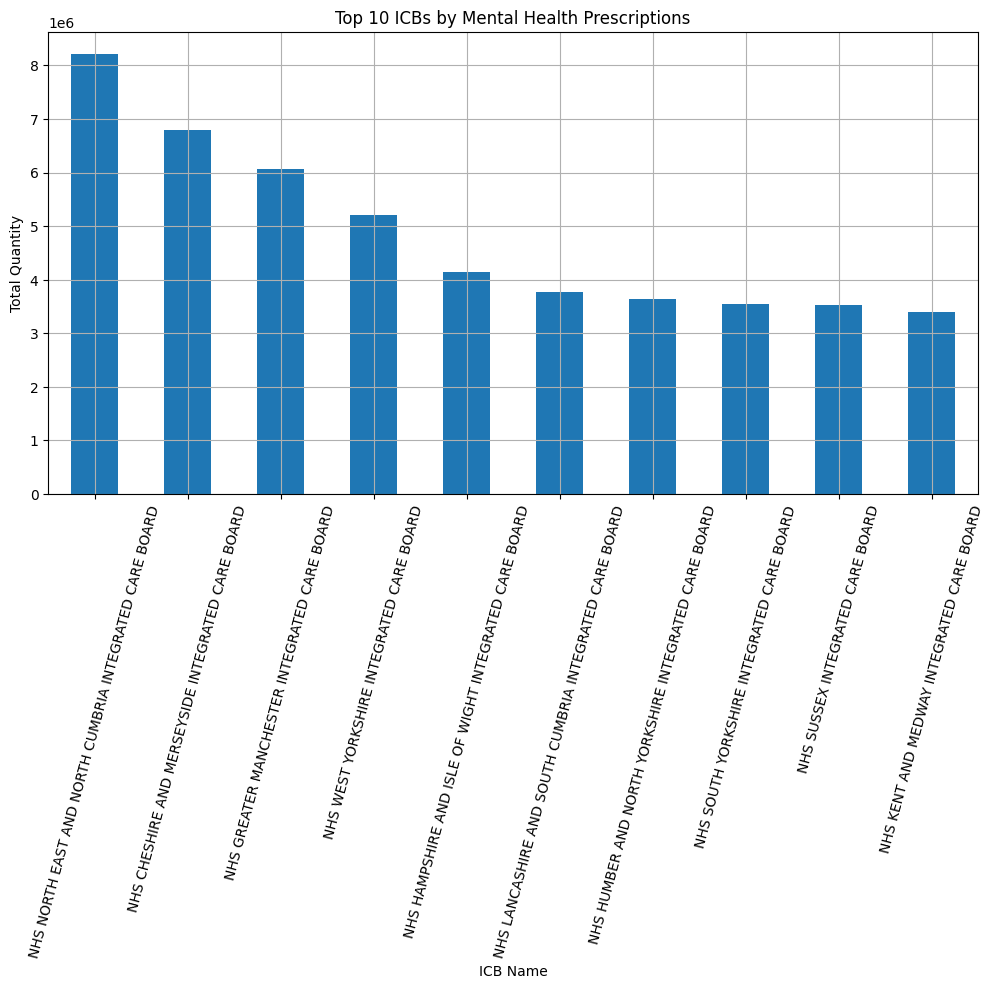

In [11]:
plt.figure(figsize=(12,6))

icb_summary.plot(kind='bar')

plt.title("Top 10 ICBs by Mental Health Prescriptions")
plt.xlabel("ICB Name")
plt.ylabel("Total Quantity")

plt.xticks(rotation=75)

plt.grid(True)

plt.show()

In [14]:
# top 20 ICBs

top_icbs = filtered_df.groupby(
    "ICB_NAME"
)["TOTAL_QUANTITY"].sum().sort_values(
    ascending=False
).head(20).index

# filter only top ICBs
top_icb_df = filtered_df[
    filtered_df["ICB_NAME"].isin(top_icbs)
]

# category comparison
top_icb_category = top_icb_df.groupby(
    ["ICB_NAME", "CATEGORY"]
)["TOTAL_QUANTITY"].sum().unstack()

print(top_icb_category)

CATEGORY                                            Antidepressant  Anxiolytic
ICB_NAME                                                                      
NHS BIRMINGHAM AND SOLIHULL INTEGRATED CARE BOARD          2124481      232828
NHS BLACK COUNTRY INTEGRATED CARE BOARD                    2232915      263028
NHS BUCKINGHAMSHIRE, OXFORDSHIRE AND BERKSHIRE ...         2892360      226355
NHS CHESHIRE AND MERSEYSIDE INTEGRATED CARE BOARD          6106721      692826
NHS DERBY AND DERBYSHIRE INTEGRATED CARE BOARD             2504409      310576
NHS DEVON INTEGRATED CARE BOARD                            2367635      327868
NHS GREATER MANCHESTER INTEGRATED CARE BOARD               5578567      497525
NHS HAMPSHIRE AND ISLE OF WIGHT INTEGRATED CARE...         3822774      329048
NHS HERTFORDSHIRE AND WEST ESSEX INTEGRATED CAR...         2206926      211402
NHS HUMBER AND NORTH YORKSHIRE INTEGRATED CARE ...         3359076      271889
NHS KENT AND MEDWAY INTEGRATED CARE BOARD           

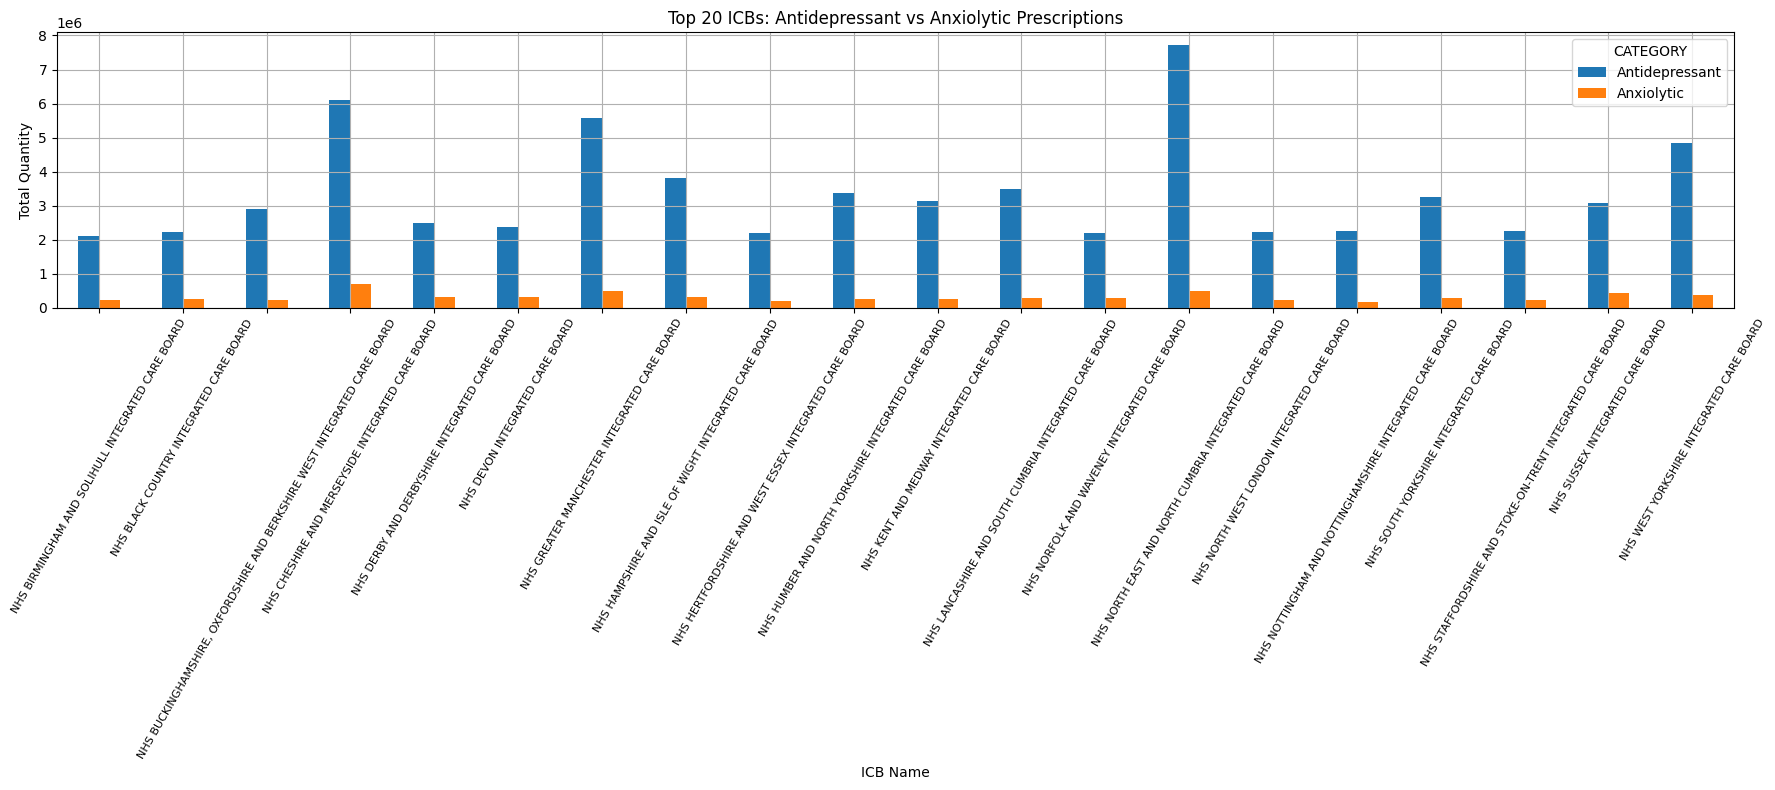

In [20]:
top_icb_category.plot(
    kind='bar',
    figsize=(18,8)
)

plt.title("Top 20 ICBs: Antidepressant vs Anxiolytic Prescriptions")

plt.xlabel("ICB Name")
plt.ylabel("Total Quantity")

plt.xticks(rotation=60, fontsize=8)

plt.grid(True)

plt.tight_layout()

plt.show()

In [21]:
monthly_trend.to_csv("monthly_trend_summary.csv")

regional_summary.to_csv("regional_summary.csv")

drug_summary.to_csv("drug_summary.csv")

top_icb_category.to_csv("icb_category_summary.csv")

print("All files saved successfully")

All files saved successfully


monthly trend by antidepressant vs anxiolytic prescribing

In [22]:
monthly_category = filtered_df.groupby(
    ["YEAR_MONTH", "CATEGORY"]
)["TOTAL_QUANTITY"].sum().unstack()

print(monthly_category)

CATEGORY    Antidepressant  Anxiolytic
YEAR_MONTH                            
2026-03          102579319    10439519


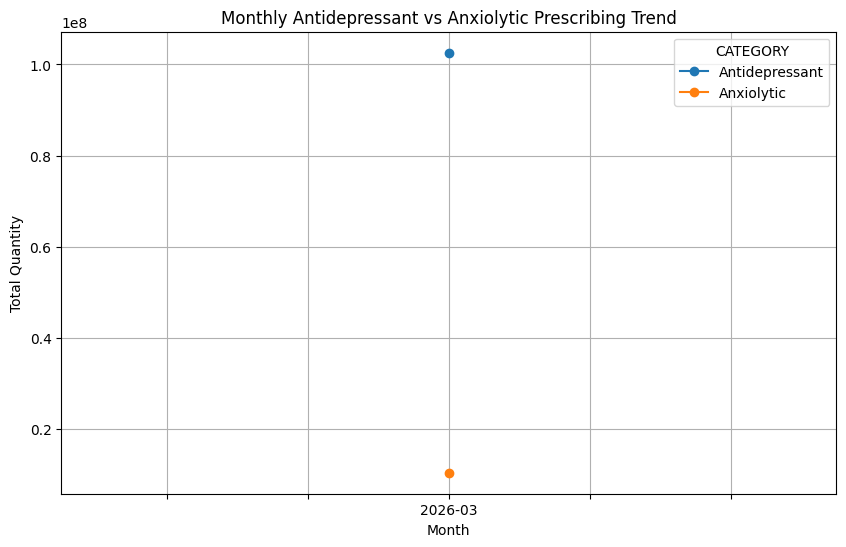

In [23]:
monthly_category.plot(
    kind='line',
    figsize=(10,6),
    marker='o'
)

plt.title("Monthly Antidepressant vs Anxiolytic Prescribing Trend")

plt.xlabel("Month")
plt.ylabel("Total Quantity")

plt.grid(True)

plt.show()